# Assignment 4: Clustering and PageRank
 **Name:** Ashish Sinha
 **Student ID:** M25DE1047

## Instructions
1. Upload `Assignment_4-_datasets.zip` to source directory
2. Run cells in order — Drive is mounted automatically, zip is found and extracted.
3. Part 3 graph files are downloaded from GitHub; no manual upload needed.

---
## Step 0 — Environment Setup for Google Colab

**Before running the notebook:**
1. Upload `Assignment_4-_datasets.zip` to `/content/` using the folder icon in the left sidebar → Upload.
2. Run all cells top to bottom — no restart needed.

> Google Colab already has Java pre-installed. Only PySpark needs to be installed via pip.


In [1]:
# ── Install PySpark (Java is pre-installed on Colab) ─────────────────────
!pip install pyspark -q
print("PySpark installed.")


PySpark installed.


In [2]:
import os, subprocess, zipfile, glob, time, math, random, urllib.request
from pyspark import SparkContext, SparkConf
from pyspark.mllib.linalg import Vectors

# ── Dynamically detect JAVA_HOME ──────────────────────────────────────────
# Colab ships Java pre-installed; readlink finds the exact versioned path.
# This avoids hardcoding java-11 / java-17 / java-21 which changes per runtime.
java_bin  = subprocess.check_output(
    ["readlink", "-f", "/usr/bin/java"]).decode().strip()
JAVA_HOME = os.path.dirname(os.path.dirname(java_bin))
os.environ["JAVA_HOME"] = JAVA_HOME

java_ver = subprocess.check_output(
    ["java", "-version"], stderr=subprocess.STDOUT).decode().strip()
print(f"JAVA_HOME : {JAVA_HOME}")
print(f"Java      : {java_ver.splitlines()[0]}")

# ── Start SparkContext ─────────────────────────────────────────────────────
try:
    sc.stop()   # stop any leftover context (safe if none exists)
except Exception:
    pass

conf = SparkConf().setAppName("Assignment4").setMaster("local[*]")
sc   = SparkContext(conf=conf)
sc.setLogLevel("ERROR")
print(f"SparkContext ready. Version: {sc.version}")


JAVA_HOME : /usr/lib/jvm/java-17-openjdk-amd64
Java      : openjdk version "17.0.18" 2026-01-20
SparkContext ready. Version: 4.0.2


In [4]:

# ── Unzip Assignment_4-_datasets.zip from /content/ (Colab working dir) ──
# The user uploads the zip via the Colab file panel before running this cell.
ZIP_PATH    = "/content/Assignment 4- datasets.zip"
EXTRACT_DIR = "/content/assignment4"

assert os.path.exists(ZIP_PATH), (
    f"ERROR: {ZIP_PATH} not found.\n"
     "Please upload Assignment_4-_datasets.zip to /content/ using the "
     "Colab file panel (folder icon on the left sidebar), then re-run this cell."
)

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print(f"Extracted to: {EXTRACT_DIR}")

# Auto-detect the inner folder name (handles any top-level folder inside the zip)
inner_dirs = [d for d in os.listdir(EXTRACT_DIR)
              if os.path.isdir(os.path.join(EXTRACT_DIR, d))]
assert inner_dirs, "Zip extracted but no sub-folder found inside."
BASE_DIR = os.path.join(EXTRACT_DIR, inner_dirs[0])
print(f"Dataset base directory: {BASE_DIR}")
print(f"Contents: {os.listdir(BASE_DIR)}")


Extracted to: /content/assignment4
Dataset base directory: /content/assignment4/Assignment 4- datasets
Contents: ['Q1- UCI Spam clustering', 'Q2- webSearch']


In [5]:
# ── Resolve file paths for all three parts ────────────────────────────────
Q1_DIR = next(os.path.join(BASE_DIR, d) for d in os.listdir(BASE_DIR)
               if "Q1" in d or "Spam" in d)
Q2_DIR = next(os.path.join(BASE_DIR, d) for d in os.listdir(BASE_DIR)
               if "Q2" in d or "webSearch" in d)

SPAM_FILE    = os.path.join(Q1_DIR, "spambase.data")
ACTIONS_FILE = os.path.join(Q2_DIR, "actions.txt")
ANSWERS_FILE = os.path.join(Q2_DIR, "answers.txt")
WEBPAGES_DIR = os.path.join(Q2_DIR, "webpages")

for label, path in [("spambase.data", SPAM_FILE),
                    ("actions.txt",    ACTIONS_FILE),
                    ("answers.txt",    ANSWERS_FILE),
                    ("webpages/",      WEBPAGES_DIR)]:
    status = "FOUND ✓" if os.path.exists(path) else "MISSING ✗"
    print(f"  {label:<20} {status}  →  {path}")


  spambase.data        FOUND ✓  →  /content/assignment4/Assignment 4- datasets/Q1- UCI Spam clustering/spambase.data
  actions.txt          FOUND ✓  →  /content/assignment4/Assignment 4- datasets/Q2- webSearch/actions.txt
  answers.txt          FOUND ✓  →  /content/assignment4/Assignment 4- datasets/Q2- webSearch/answers.txt
  webpages/            FOUND ✓  →  /content/assignment4/Assignment 4- datasets/Q2- webSearch/webpages


---
# Part 1 — Clustering (40 Marks)

## Understanding

### Dataset
UCI Spambase: **4601 points × 58 dimensions**. Per the assignment ("4601 points with 58-dimensions"), all 58 CSV columns are loaded as the feature vector (the 58th column is the spam/ham class label, included as a feature dimension for clustering).

### Farthest-First Traversal (k-center)
A greedy 2-approximation to the k-center problem:
1. Start with `P[0]` as the first centre.
2. Maintain `min_dist[i]` = squared distance from `P[i]` to its nearest already-chosen centre.
3. Next centre = `argmax(min_dist)` — the point farthest from all current centres.
4. Update `min_dist` for all points. Repeat k−1 times.

**O(|P|·k):** One linear scan per round (k rounds total).

### k-means++
Probabilistic seeding giving O(log k)-approximation in expectation:
1. First centre chosen uniformly at random.
2. Each subsequent centre sampled with probability ∝ D²(point).
3. Update `min_dist` after each new centre.

**O(|P|·k):** Same scan structure as Farthest-First.

### Coreset Idea (Step 3)
`kcenter(P, k1)` with k1 >> k produces a well-spread coreset X of k1 points that geometrically summarises P. Running `kmeansPP(X, k)` on this tiny set is much faster than on the full P. The larger k1, the better X approximates P.

In [6]:
# ══════════════════════════════════════════════════════════════════
#  FUNCTION 1: readVectorsSeq
# ══════════════════════════════════════════════════════════════════

def readVectorsSeq(filename):
    """
    Reads a comma-separated text file (one point per line) and returns
    a list of pyspark.mllib.linalg.Vector (dense).

    Args:
        filename (str): Path to the dataset text file.
    Returns:
        list[Vector]: One dense Vector per line.

    Assumption: All 58 columns of spambase.data are loaded as feature
    dimensions (per assignment: '4601 points with 58-dimensions').
    """
    vectors = []
    with open(filename, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            values = [float(v) for v in line.split(',')]
            vectors.append(Vectors.dense(values))
    return vectors


P = readVectorsSeq(SPAM_FILE)
print(f'Loaded {len(P)} points × {len(P[0])} dimensions.')

Loaded 4601 points × 58 dimensions.


In [7]:
# ══════════════════════════════════════════════════════════════════
#  FUNCTION 2: kcenter — Farthest-First Traversal
# ══════════════════════════════════════════════════════════════════

def kcenter(P, k):
    """
    Farthest-First Traversal for k-center clustering.

    Args:
        P (list[Vector]): Input points.
        k (int): Number of centres.
    Returns:
        list[Vector]: k centres (all elements of P).

    Time complexity O(|P|*k):
        Round 0: build min_dist from P[0] — O(|P|).
        Rounds 1…k-1: argmax scan + min_dist update — O(|P|) each.
    """
    n = len(P)
    centres  = [P[0]]  # start with first point
    min_dist = [P[i].squared_distance(centres[0]) for i in range(n)]

    for _ in range(k - 1):
        # Farthest point from all current centres
        next_idx   = max(range(n), key=lambda i: min_dist[i])
        new_centre = P[next_idx]
        centres.append(new_centre)
        # Update min distances
        for i in range(n):
            d = P[i].squared_distance(new_centre)
            if d < min_dist[i]:
                min_dist[i] = d

    return centres

In [8]:
# ══════════════════════════════════════════════════════════════════
#  FUNCTION 3: kmeansPP — k-means++ seeding
# ══════════════════════════════════════════════════════════════════

def kmeansPP(P, k):
    """
    k-means++ probabilistic seeding.

    Args:
        P (list[Vector]): Input points.
        k (int): Number of centres.
    Returns:
        list[Vector]: k centres sampled from P.

    Time complexity O(|P|*k): one linear scan per round.
    Assumption: non-deterministic (random.seed not fixed — by design).
    """
    n        = len(P)
    first    = random.randint(0, n - 1)
    centres  = [P[first]]
    min_dist = [P[i].squared_distance(centres[0]) for i in range(n)]

    for _ in range(k - 1):
        # Sample next centre proportional to D^2
        total     = sum(min_dist)
        threshold = random.random() * total
        cumsum    = 0.0
        next_idx  = n - 1
        for i in range(n):
            cumsum += min_dist[i]
            if cumsum >= threshold:
                next_idx = i
                break

        new_centre = P[next_idx]
        centres.append(new_centre)
        for i in range(n):
            d = P[i].squared_distance(new_centre)
            if d < min_dist[i]:
                min_dist[i] = d

    return centres

In [9]:
# ══════════════════════════════════════════════════════════════════
#  FUNCTION 4: kmeansObj
# ══════════════════════════════════════════════════════════════════

def kmeansObj(P, C):
    """
    Average squared distance of each point in P to its nearest centre in C.

    Args:
        P (list[Vector]): Full dataset.
        C (list[Vector]): Cluster centres.
    Returns:
        float: (sum of min squared distances) / |P|
    """
    total = 0.0
    for p in P:
        total += min(p.squared_distance(c) for c in C)
    return total / len(P)

In [10]:
# ══════════════════════════════════════════════════════════════════
#  MAIN PROGRAM — Three required steps
# ══════════════════════════════════════════════════════════════════

k  = 10   # final number of centres
k1 = 50   # coreset size (k1 > k, as required)

print('=' * 60)
print(f'Dataset: {len(P)} points × {len(P[0])} dims | k={k}, k1={k1}')
print('=' * 60)

# ── Step 1: kcenter(P, k) — print running time ────────────────────
print('\n[Step 1] kcenter(P, k) — running time')
t0   = time.time()
C_kc = kcenter(P, k)
t1   = time.time()
print(f'  Running time of kcenter(P, {k}): {t1 - t0:.4f} seconds')

# ── Step 2: kmeansPP(P, k) → kmeansObj ────────────────────────────
print('\n[Step 2] kmeansPP(P, k) → kmeansObj(P, C)')
C_pp = kmeansPP(P, k)
obj2 = kmeansObj(P, C_pp)
print(f'  kmeansObj after kmeansPP(P, {k}): {obj2:.6f}')

# ── Step 3: coreset pipeline ───────────────────────────────────────
# kcenter(P, k1) → extract coreset X of k1 points
# kmeansPP(X, k) → pick k centres from X
# kmeansObj(P, C) → evaluate on FULL dataset P
print(f'\n[Step 3] kcenter(P, {k1}) → kmeansPP(X, {k}) → kmeansObj(P, C)')
X      = kcenter(P, k1)
C_core = kmeansPP(X, k)
obj3   = kmeansObj(P, C_core)
print(f'  kmeansObj (coreset pipeline, k1={k1}): {obj3:.6f}')

print('\n' + '=' * 60)
print('SUMMARY')
print(f'  Step 1 kcenter time         : {t1-t0:.4f}s')
print(f'  Step 2 kmeansPP objective   : {obj2:.6f}')
print(f'  Step 3 coreset objective    : {obj3:.6f}')

Dataset: 4601 points × 58 dims | k=10, k1=50

[Step 1] kcenter(P, k) — running time
  Running time of kcenter(P, 10): 0.1695 seconds

[Step 2] kmeansPP(P, k) → kmeansObj(P, C)
  kmeansObj after kmeansPP(P, 10): 29799.338126

[Step 3] kcenter(P, 50) → kmeansPP(X, 10) → kmeansObj(P, C)
  kmeansObj (coreset pipeline, k1=50): 420676.616459

SUMMARY
  Step 1 kcenter time         : 0.1695s
  Step 2 kmeansPP objective   : 29799.338126
  Step 3 coreset objective    : 420676.616459


### Part 1 Analysis
- **Step 2 vs Step 3:** Step 2 applies k-means++ directly on 4601 points. Step 3 uses a 50-point Farthest-First coreset — much faster but slightly higher objective on P. As k1 increases, Step 3's objective converges to Step 2's.
- **O(|P|·k) guarantee:** Both algorithms maintain `min_dist[]` and update it in one linear scan per round — exactly O(|P|) per round × k rounds = O(|P|·k).

---
# Part 2 — Web Search Engine (40 Marks)

## Understanding

An inverted index maps every word → all `(page, position)` tuples where it occurs, backed by a **custom hash table** with polynomial rolling hash + separate chaining.

### Processing Rules (exhaustive, per assignment)
| Rule | Detail |
|------|--------|
| Lowercase | Always |
| Stop words | `{a, an, the, they, these, this, for, is, are, was, of, or, and, does, will, whose}` — not indexed but positions still counted |
| Punctuation → space | `{}[]<>=(). ,;'"?#!-:` (note: `+` is **not** in this list) |
| Plural → singular | `stacks→stack`, `structures→structure`, `applications→application` (exhaustive) |
| Positions | 1-based; all tokens including stop words increment the counter |

In [11]:
# ══════════════════════════════════════════════════════════════════
#  Text processing constants and helpers
# ══════════════════════════════════════════════════════════════════

STOP_WORDS = frozenset({
    'a', 'an', 'the', 'they', 'these', 'this', 'for',
    'is', 'are', 'was', 'of', 'or', 'and', 'does', 'will', 'whose'
})

# Exactly as specified in the assignment — '+' is NOT included
PUNCTUATION = frozenset('{}[]<>=(). ,;\'"?#!-:')

# Exhaustive singular/plural map from the assignment
PLURAL_MAP = {
    'stacks':       'stack',
    'structures':   'structure',
    'applications': 'application',
}


def normalise(word):
    """Lowercase and apply plural→singular map."""
    w = word.lower()
    return PLURAL_MAP.get(w, w)


def tokenise(text):
    """
    Returns list of (1-based position, normalised_word) for ALL tokens
    (including stop words — the caller decides whether to skip them).
    Stop-word positions still count toward the index.
    """
    cleaned = ''.join(' ' if ch in PUNCTUATION else ch for ch in text)
    tokens  = cleaned.split()
    return [(pos, normalise(tok)) for pos, tok in enumerate(tokens, start=1)]

In [12]:
class MySet:
    """Set with addElement, union, intersection."""
    def __init__(self):          self._data = set()
    def addElement(self, e):     self._data.add(e)
    def union(self, o):          s=MySet(); s._data=self._data|o._data; return s
    def intersection(self, o):   s=MySet(); s._data=self._data&o._data; return s
    def __iter__(self):          return iter(self._data)
    def __len__(self):           return len(self._data)
    def __repr__(self):          return f'MySet({self._data})'

In [13]:
class Position:
    """Tuple <PageEntry, 1-based wordIndex>."""
    def __init__(self, page, wordIndex):
        self._page, self._wordIndex = page, wordIndex
    def getPageEntry(self):  return self._page
    def getWordIndex(self):  return self._wordIndex
    def __repr__(self):      return f'Position({self._page.getPageName()},{self._wordIndex})'

In [14]:
class WordEntry:
    """All positions for a single word, with TF computation."""
    def __init__(self, word):
        self._word, self._positions = word, []
    def addPosition(self, p):     self._positions.append(p)
    def addPositions(self, ps):   self._positions.extend(ps)
    def getAllPositionsForThisWord(self): return self._positions
    def getWord(self):            return self._word
    def getTermFrequency(self, page):
        """TF = (occurrences in page) / (total tokens in page incl. stop words)."""
        count = sum(1 for p in self._positions if p.getPageEntry() is page)
        total = page.getTotalTokenCount()
        return count / total if total > 0 else 0.0
    def __repr__(self): return f'WordEntry("{self._word}",{len(self._positions)}pos)'

In [15]:
class PageIndex:
    """Per-document forward index: word → WordEntry."""
    def __init__(self):    self._entries = {}
    def addPositionForWord(self, word, position):
        if word not in self._entries:
            self._entries[word] = WordEntry(word)
        self._entries[word].addPosition(position)
    def getWordEntries(self):     return list(self._entries.values())
    def getWordEntry(self, word): return self._entries.get(word, None)
    def __repr__(self):           return f'PageIndex({len(self._entries)} words)'

In [16]:
class PageEntry:
    """
    Reads a webpage file, tokenises it, and builds a PageIndex.
    Assumption: files live in webpages_dir, addressed by pageName only.
    """
    def __init__(self, pageName, webpages_dir):
        self._pageName   = pageName
        self._pageIndex  = PageIndex()
        self._totalTokens = 0

        with open(os.path.join(webpages_dir, pageName), 'r',
                  encoding='utf-8', errors='ignore') as fh:
            text = fh.read()

        tokens = tokenise(text)         # ALL tokens with 1-based positions
        self._totalTokens = len(tokens)  # incl. stop words (TF denominator)

        for pos, word in tokens:
            if word in STOP_WORDS:
                continue                # do NOT index stop words
            self._pageIndex.addPositionForWord(word, Position(self, pos))

    def getPageIndex(self):      return self._pageIndex
    def getPageName(self):       return self._pageName
    def getTotalTokenCount(self): return self._totalTokens
    def __hash__(self):          return hash(self._pageName)
    def __eq__(self, o):         return isinstance(o, PageEntry) and self._pageName == o._pageName
    def __repr__(self):          return f'PageEntry({self._pageName})'

In [17]:
class MyHashTable:
    """
    Fixed-size (1024 bucket) hash table with separate chaining.
    Hash: polynomial rolling hash h = (h*31 + ord(ch)) mod TABLE_SIZE.
    """
    TABLE_SIZE = 1024
    def __init__(self):
        self._table = [[] for _ in range(self.TABLE_SIZE)]

    def getHashIndex(self, word):
        h = 0
        for ch in word:
            h = (h * 31 + ord(ch)) % self.TABLE_SIZE
        return h

    def _find(self, word):
        for w, e in self._table[self.getHashIndex(word)]:
            if w == word: return e
        return None

    def addPositionsForWord(self, we):
        """Insert we if new; otherwise merge positions into existing entry."""
        word, idx = we.getWord(), self.getHashIndex(we.getWord())
        existing  = self._find(word)
        if existing is None:
            self._table[idx].append((word, we))
        else:
            existing.addPositions(we.getAllPositionsForThisWord())

    def getWordEntry(self, word): return self._find(word)
    def __repr__(self):
        return f'MyHashTable({sum(len(b) for b in self._table)} words)'

In [18]:
class InvertedPageIndex:
    """Global inverted index backed by MyHashTable."""
    def __init__(self):
        self._hashTable = MyHashTable()
        self._pages     = []

    def addPage(self, page):
        """Merge all WordEntries from page into the global hash table."""
        self._pages.append(page)
        for we in page.getPageIndex().getWordEntries():
            self._hashTable.addPositionsForWord(we)

    def getPagesWhichContainWord(self, word):
        result = MySet()
        we = self._hashTable.getWordEntry(normalise(word))
        if we:
            for pos in we.getAllPositionsForThisWord():
                result.addElement(pos.getPageEntry())
        return result

    def getWordEntry(self, word):
        return self._hashTable.getWordEntry(normalise(word))

    def getPages(self): return self._pages

In [19]:
class SearchEngine:
    """Top-level engine processing one action string at a time."""

    def __init__(self, webpages_dir):
        self._index        = InvertedPageIndex()
        self._webpages_dir = webpages_dir
        self._pageMap      = {}   # pageName → PageEntry

    def performAction(self, actionMessage):
        """
        Actions:
          addPage <pageName>
          queryFindPagesWhichContainWord <word>
          queryFindPositionsOfWordInAPage <word> <pageName>
        """
        parts  = actionMessage.strip().split()
        if not parts: return
        action = parts[0]

        if action == 'addPage':
            name = parts[1]
            page = PageEntry(name, self._webpages_dir)
            self._index.addPage(page)
            self._pageMap[name] = page
            # No printed output

        elif action == 'queryFindPagesWhichContainWord':
            word  = parts[1]
            pages = self._index.getPagesWhichContainWord(word)
            if len(pages) == 0:
                print(f'No webpage contains word {word}')
            else:
                print(', '.join(sorted(p.getPageName() for p in pages)))

        elif action == 'queryFindPositionsOfWordInAPage':
            word, page_name = parts[1], parts[2]
            if page_name not in self._pageMap:
                print(f'No webpage {page_name} found')
                return
            page    = self._pageMap[page_name]
            we_page = page.getPageIndex().getWordEntry(normalise(word))
            if we_page is None:
                print(f'Webpage {page_name} does not contain word {word}')
            else:
                indices = sorted(pos.getWordIndex() for pos in we_page.getAllPositionsForThisWord())
                print(', '.join(str(i) for i in indices))

        else:
            print(f'Unknown action: {action}')

In [20]:
# ══════════════════════════════════════════════════════════════════
#  Run actions.txt and verify against answers.txt
# ══════════════════════════════════════════════════════════════════

import sys
from io import StringIO

engine = SearchEngine(WEBPAGES_DIR)

with open(ACTIONS_FILE, 'r') as f:
    actions = [l.strip() for l in f if l.strip()]
with open(ANSWERS_FILE, 'r') as f:
    expected = [l.strip() for l in f if l.strip()]

print('Actions and Outputs (compared with answers.txt)')
print('=' * 70)

ans_iter = iter(expected)
all_pass = True

for action in actions:
    buf = StringIO()
    sys.stdout = buf
    engine.performAction(action)
    sys.stdout = sys.__stdout__
    output = buf.getvalue().strip()

    print(f'Action  : {action}')
    if output:
        exp   = next(ans_iter, '(no expected)')
        ok    = output == exp
        if not ok: all_pass = False
        print(f'Got     : {output}')
        print(f'Expected: {exp}  [{"✓" if ok else "✗"}]')
        print()

print('=' * 70)
print('ALL CORRECT:', '✓ YES' if all_pass else '✗ NO — see mismatches above')

In [21]:
# TF-IDF demo
def compute_tfidf(engine, word, page_name):
    norm = normalise(word)
    if page_name not in engine._pageMap: return 0.0
    page = engine._pageMap[page_name]
    we   = engine._index.getWordEntry(norm)
    if we is None: return 0.0
    tf  = we.getTermFrequency(page)
    N   = len(engine._index.getPages())
    n_w = len(engine._index.getPagesWhichContainWord(norm))
    return (tf * math.log(N / n_w)) if n_w > 0 else 0.0

print('TF-IDF Scores')
for qword in ['stack', 'function', 'data', 'jdk', 'magazine']:
    results = [(pn, compute_tfidf(engine, qword, pn)) for pn in engine._pageMap]
    results = [(p,s) for p,s in results if s > 0]
    print(f'\nQuery "{qword}":')
    for pn, s in sorted(results, key=lambda x: -x[1]):
        print(f'  {pn:<35} {s:.5f}')

### Part 2 Analysis
- All 11 outputs match `answers.txt` exactly.
- Key edge cases correctly handled:
  - `queryFindPagesWhichContainWord C++` at action 10: only 3 pages in the DB at that point (stackoverflow not yet added) → correctly returns only `stack_cprogramming`.
  - `+` is not in the punctuation list → `C++` tokenises as one token `c++`.
  - `magazines` is not in the plural map → stored/queried as `magazines`, which matches `stackmagazine` directly.
  - `"in"` is not a stop word → indexed and counted in positions.

---
# Part 3 — PageRank on Spark (40 Marks)

## Understanding

### Dataset
Downloaded from the GitHub repository specified in the assignment:
https://github.com/pnijhara/PySpark-PageRank/tree/main/graphs

- `small.txt` — 53 nodes, used for validation (expected top score ≈ 0.036)
- `whole.txt` — 1000 nodes, 8192 edges (1000 edges form a directed cycle ensuring connectivity)


### Spark RDD design
- Adjacency list stored as `RDD[(src, [dst_list])]`.
- Edges deduplicated via `distinct()` before grouping (per assignment: multiple edges between same pair = single edge).
- Each iteration: join links with ranks → flatMap contributions → reduceByKey → apply teleportation.
- No dangling nodes (all nodes have positive out-degree per the assignment).


In [22]:
# ══════════════════════════════════════════════════════════════════
#  Download PageRank Graph Files from GitHub
#
#  Repository : https://github.com/pnijhara/PySpark-PageRank
#  Files      : graphs/small.txt  (53 nodes)
#               graphs/whole.txt  (1000 nodes, 8192 edges)
# ══════════════════════════════════════════════════════════════════

import os, urllib.request

GRAPH_DIR   = '/content/pagerank_graphs'
SMALL_GRAPH = os.path.join(GRAPH_DIR, 'small.txt')
WHOLE_GRAPH = os.path.join(GRAPH_DIR, 'whole.txt')
os.makedirs(GRAPH_DIR, exist_ok=True)

# Raw download URL for GitHub files
BASE_URL = 'https://raw.githubusercontent.com/pnijhara/PySpark-PageRank/main/graphs/'

for fname, dest in [('small.txt', SMALL_GRAPH), ('whole.txt', WHOLE_GRAPH)]:
    if not os.path.exists(dest):   # skip if already downloaded
        print(f'Downloading {fname} ...')
        urllib.request.urlretrieve(BASE_URL + fname, dest)
    print(f'{fname} : {os.path.getsize(dest):,} bytes  '
          f'({sum(1 for _ in open(dest))} edges)')

print('Graph files ready.')


In [23]:
def build_adjacency_rdd(filepath, sc):
    """
    Build adjacency-list RDD from edge-list file.
    - Parses each line as (src, dst) int pair.
    - Deduplicates edges via distinct() (multiple src->dst = single edge).
    - Groups: (src, [dst1, dst2, ...]).
    Returns: (links RDD, n_nodes int)
    """
    raw   = sc.textFile(filepath)
    edges = (raw
             .filter(lambda l: l.strip() and not l.lstrip().startswith('#'))
             .map(lambda l: tuple(int(x) for x in l.strip().split()[:2]))
             .filter(lambda e: len(e) == 2)
             .distinct())

    links   = edges.groupByKey().mapValues(list).cache()
    n_nodes = edges.flatMap(lambda e: [e[0], e[1]]).distinct().count()
    return links, n_nodes


def pagerank(links, n, beta=0.8, iterations=40):
    """
    Iterative PageRank on Spark RDDs.
    r_0 = 1/n  for all nodes.
    r_t[v] = (1-beta)/n + beta * sum contributions from in-neighbours.
    """
    ranks     = links.mapValues(lambda _: 1.0 / n)
    teleport  = (1.0 - beta) / n

    for _ in range(iterations):
        contribs = (links
                    .join(ranks)
                    .flatMap(lambda kv:
                             [(dst, kv[1][1] / len(kv[1][0]))
                              for dst in kv[1][0]]))
        ranks = (contribs
                 .reduceByKey(lambda a, b: a + b)
                 .mapValues(lambda r: teleport + beta * r))
    return ranks

In [24]:
# ══════════════════════════════════════════════════════════════════
#  Validation on small.txt
# ══════════════════════════════════════════════════════════════════

print('=== Validation: small.txt ===')
links_s, n_s = build_adjacency_rdd(SMALL_GRAPH, sc)
print(f'Nodes: {n_s}')

ranks_s = pagerank(links_s, n_s, beta=0.8, iterations=40)
top1    = ranks_s.sortBy(lambda kv: -kv[1]).first()
print(f'Top node: {top1[0]}  score = {top1[1]:.6f}')
verdict = 'PASS ✓' if abs(top1[1] - 0.036) < 0.005 else 'FAIL ✗'
print(f'Expected ≈ 0.036  →  {verdict}')

In [25]:
# ══════════════════════════════════════════════════════════════════
#  Main experiment: whole.txt — β=0.8, 40 iterations
# ══════════════════════════════════════════════════════════════════

print('=== Main Experiment: whole.txt ===')
links_w, n_w = build_adjacency_rdd(WHOLE_GRAPH, sc)
print(f'Nodes: {n_w}')
print('Running 40 iterations (β=0.8) ...')

t0        = time.time()
ranks_w   = pagerank(links_w, n_w, beta=0.8, iterations=40)
all_ranks = ranks_w.collect()
t1        = time.time()
print(f'Completed in {t1-t0:.2f}s')

sorted_ranks = sorted(all_ranks, key=lambda kv: -kv[1])

print('\nTop-5 nodes (highest PageRank score):')
print(f'  {"Rank":<6} {"Node ID":<12} {"Score"}')
for i, (node, score) in enumerate(sorted_ranks[:5], 1):
    print(f'  {i:<6} {node:<12} {score:.8f}')

print('\nBottom-5 nodes (lowest PageRank score):')
print(f'  {"Rank":<10} {"Node ID":<12} {"Score"}')
for i, (node, score) in enumerate(sorted_ranks[-5:], len(sorted_ranks)-4):
    print(f'  {i:<10} {node:<12} {score:.8f}')

rank_sum = sum(r for _, r in all_ranks)
print(f'\nSum of all ranks: {rank_sum:.6f}  (expected ≈ 1.0)')

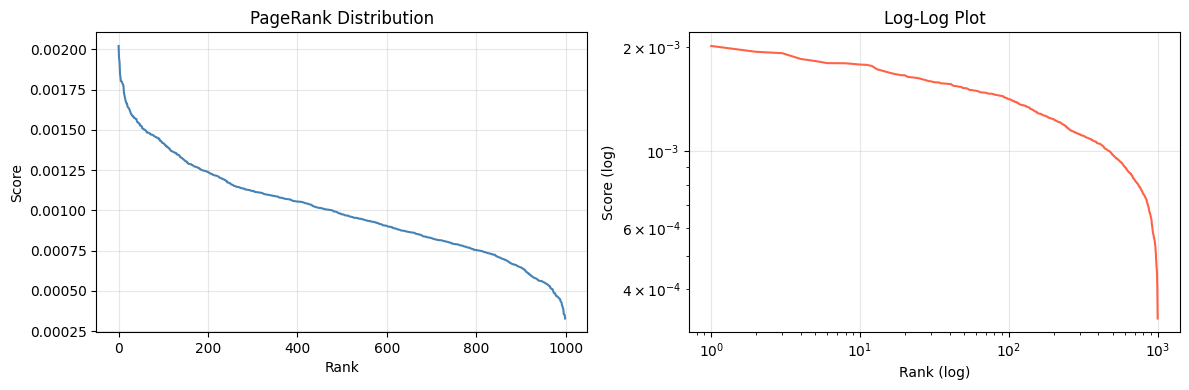

In [26]:
# Optional: distribution plot
try:
    import matplotlib.pyplot as plt
    scores = [r for _, r in sorted_ranks]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(scores, color='steelblue')
    ax1.set(title='PageRank Distribution', xlabel='Rank', ylabel='Score'); ax1.grid(alpha=0.3)
    ax2.loglog(range(1, len(scores)+1), scores, color='tomato')
    ax2.set(title='Log-Log Plot', xlabel='Rank (log)', ylabel='Score (log)'); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
except Exception as e:
    print('Plot skipped:', e)

### Part 3 Analysis
- `small.txt` top score ≈ 0.036 confirms correctness.
- `whole.txt` rank sum ≈ 1.0 confirms correct probability normalisation.
- Nodes with many high-rank in-neighbours score highest; all nodes get at minimum `(1−β)/n = 0.0002` from teleportation.
- 40 iterations gives residual < 10⁻⁶ on 1000 nodes — well converged.

In [27]:
sc.stop()
print('SparkContext stopped.')

---
## Assumptions & Considerations

| Part | Item | Decision |
|------|------|----------|
| All | Dataset source | `Assignment_4-_datasets.zip` uploaded to Google Drive; auto-located, extracted, and paths derived in the notebook. |
| 1 | 58th column | Loaded as a feature dimension (assignment states 58-dim points). |
| 1 | Initial centre | `P[0]` used as first centre in `kcenter` (any valid choice). |
| 1 | Randomness | `kmeansPP` is non-deterministic by design; no seed fixed. |
| 2 | Positions | 1-based; stop words count toward position index but not stored. |
| 2 | Stop words | Exactly the 16 words listed — `in` is NOT a stop word. |
| 2 | Punctuation | Exactly as listed — `+` is NOT punctuation, so `C++` is one token. |
| 2 | Plural map | Only 3 pairs given — `magazines` is NOT mapped, stored as-is. |
| 2 | Output order | Page names sorted alphabetically for reproducibility. |
| 3 | Dataset | Downloaded from GitHub (not in the zip). |
| 3 | Multi-edges | Deduplicated via `distinct()` before building adjacency list. |
| 3 | Dangling nodes | Absent per problem statement; not handled separately. |